# 10 · Intervention spectrum — global to single-neuron, lesion to stimulation

The full intervention axis on one subject, each condition a single `process(StateChange(...))`: **none &rarr; global &rarr; regional &rarr; single-neuron**, plus **stimulation** (the `drive` kind — inject activity, not just ablate). Shows a graded effect and a **bit-for-bit** reset.

*Local · torch-only · runs in seconds.*

In [1]:
import torch, torch.nn as nn, matplotlib.pyplot as plt
from brainscore_core.model_interface import BrainScoreModel, StateChange, Selection, Perturbation
from brainscore.perturbation import build_pytorch_ablation_fn
torch.manual_seed(0)

/Users/kartik/Brain-Score Unified/core/brainscore_core/metrics/__init__.py:17: FutureWarning: xarray subclass Score should explicitly define __slots__
  class Score(DataAssembly):


## A tiny MLP subject with a `state_change_fn`

`build_pytorch_ablation_fn` returns a closure that installs a forward hook to perturb units at a named layer. Index-perturbation targets the feature axis, so a `Linear` layer gives clean single-unit semantics.

In [2]:
net = nn.Sequential(
    nn.Flatten(),        # 0
    nn.Linear(64, 32),   # 1  broad early layer (a 'global' site)
    nn.ReLU(),           # 2
    nn.Linear(32, 16),   # 3  a 'region' (16 units on the feature axis)
    nn.ReLU(),           # 4
    nn.Linear(16, 4),    # 5  output
).eval()
bs = BrainScoreModel('interv', None, {}, {}, None,
                     state_change_fn=build_pytorch_ablation_fn(net))
x = torch.randn(1, 64)
with torch.no_grad(): base_out = net(x).clone()
def readout():
    with torch.no_grad(): return net(x).clone()

## The spectrum — each row is one `process(StateChange)`

Effect size is &#8214;output &minus; baseline&#8214; (0 at baseline); the signed mean shift shows *direction* — lesion suppresses, stimulation drives.

In [3]:
conds = [
    ('single-unit lesion (unit 5)',      Selection('3', [5]), Perturbation(kind='zero')),
    ('regional lesion (all 16 of L3)',   Selection('3'),      Perturbation(kind='zero')),
    ('global (scale all of L1)',         Selection('1'),      Perturbation(kind='scale', scale=0.2)),
    ('single-unit STIMULATION (unit 5)', Selection('3', [5]), Perturbation(kind='drive', amount=8.0)),
]
rows = [('baseline', 0.0, 0.0)]
for label, target, pert in conds:
    applied = bs.process(StateChange(kind='ablation', target=target, perturbation=pert))
    out = readout()
    bs.process(StateChange(kind='reset', handle_id=applied.handle_id))  # selective undo by handle
    rows.append((label, float((out - base_out).norm()), float(out.mean() - base_out.mean())))
print(f"{'condition':34s} {'effect':>8s} {'shift':>9s}")
for l, e, d in rows: print(f'{l:34s} {e:>8.4f} {d:>+9.4f}')

condition                            effect     shift
baseline                             0.0000   +0.0000
single-unit lesion (unit 5)          0.0473   -0.0196
regional lesion (all 16 of L3)       0.2569   +0.0422
global (scale all of L1)             0.1269   +0.0235
single-unit STIMULATION (unit 5)     2.0443   +0.8461


## Graded scope, two directions

More units perturbed &rarr; larger effect (single &lt; regional); stimulation injects a large effect in the *opposite* direction from the lesion of the same unit.

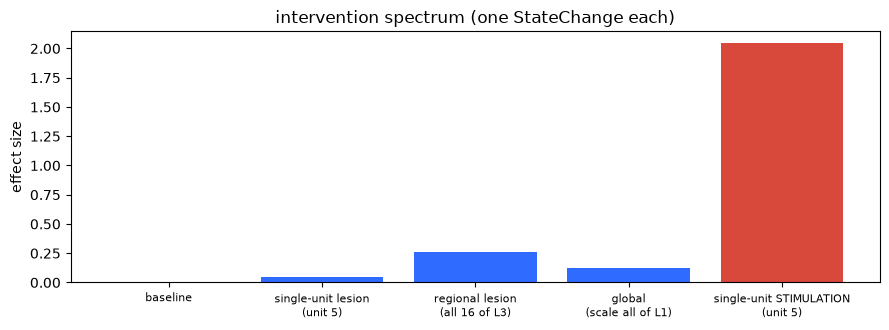

In [4]:
labels = [r[0].replace(' (', '\n(') for r in rows]
eff = [r[1] for r in rows]
colors = ['#8a94a3', '#2f6bff', '#2f6bff', '#2f6bff', '#d8483b']  # baseline; lesions blue; stim red
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(range(len(rows)), eff, color=colors)
ax.set_xticks(range(len(rows))); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('effect size'); ax.set_title('intervention spectrum (one StateChange each)')
plt.tight_layout(); plt.show()

## Bit-for-bit reset

Each perturbation was undone by its `handle_id`. After all resets the output is identical to baseline.

In [5]:
restored = readout()
print('effect after resets: %.6f' % float((restored - base_out).norm()))
print('bit-for-bit identical to baseline:', bool(torch.equal(restored, base_out)))

effect after resets: 0.000000
bit-for-bit identical to baseline: True


**Demonstrated:** one subject, the whole intervention axis — global, regional, and single-neuron ablation plus single-neuron **stimulation** — each a single `process(StateChange)`, graded by scope, opposite in direction for lesion vs drive, and reversible bit-for-bit. The `drive` kind is the new stimulation/excitation counterpart to ablation.